In [1]:
import pandas as pd
import numpy as np
import time
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score

# 1. Cargar y ordenar
df_hmm_ready = pd.read_csv('../data/processed/hmm.csv')
df_hmm_ready = df_hmm_ready.sort_values(['animal_id', 'trayectoria_id', 'date'])

# 2. Crear target por segmento y filtrar NaNs
df_hmm_ready['target_cell'] = df_hmm_ready.groupby('trayectoria_id')['cell_id'].shift(-1)
df_hmm_ready_filtered = df_hmm_ready.dropna(subset=['target_cell']).copy()

In [2]:
df_hmm_ready

,animal_id,date,hora,lon,lat,veg_low,veg_high,trayectoria_id,next_lat,next_lon,step_length,bearing,turning_angle,estado_hmm,grid_x,grid_y,cell_id,target_cell,target_num,mes_num
301,91732A,2010-04-19,14,32.50833,29.85733,0.011392,0.000634,91732A_Seg10,29.93017,32.46767,8.998029,334.185906,-0.234703,1,49,64,49_64,49_64,656,4
302,91732A,2010-04-20,14,32.46767,29.93017,0.013096,0.000745,91732A_Seg10,29.80717,32.49333,13.898980,169.739306,-2.870135,1,49,64,49_64,49_64,656,4
303,91732A,2010-04-21,14,32.49333,29.80717,0.011206,0.000614,91732A_Seg10,29.92867,32.47817,13.589038,353.828355,-3.070225,1,49,64,49_64,49_64,656,4
304,91732A,2010-04-22,14,32.47817,29.92867,0.012829,0.000729,91732A_Seg10,29.80250,32.46033,14.134539,186.995070,-2.911790,1,49,64,49_64,49_64,656,4
305,91732A,2010-04-23,14,32.46033,29.80250,0.011860,0.000651,91732A_Seg10,30.02050,32.48600,24.366432,5.821447,3.121109,0,49,64,49_64,49_64,656,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20959,91930A,2009-08-23,14,35.67167,65.04233,0.000000,0.000000,91930A_Seg1,65.03050,35.72050,2.642258,119.835414,2.002308,1,55,134,55_134,56_134,868,8
20960,91930A,2009-08-24,14,35.72050,65.03050,0.000000,0.000000,91930A_Seg1,65.02783,35.68050,1.900995,261.033103,2.464365,1,56,134,56_134,55_134,842,8
20961,91930A,2009-08-25,14,35.68050,65.02783,0.000000,0.000000,91930A_Seg1,65.02200,35.71667,1.817682,110.877872,-2.620703,1,55,134,55_134,56_134,868,8
20962,91930A,2009-08-26,14,35.71667,65.02200,0.000000,0.000000,91930A_Seg1,65.02867,35.69733,1.172394,309.251842,-2.820906,1,56,134,56_134,55_134,842,8


In [3]:
# 3. Preparar variables
df_hmm_ready_filtered['mes_num'] = pd.to_datetime(df_hmm_ready_filtered['date']).dt.month
features = ['grid_x', 'grid_y', 'step_length', 'turning_angle', 'bearing', 'estado_hmm', 'veg_low', 'veg_high', 'mes_num']

X = df_hmm_ready_filtered[features]
y_all_raw = df_hmm_ready_filtered['target_cell'] # IMPORTANTE: usar el filtered

In [4]:
#Split temporal global: mejor caso RandomForest con un 63%

"""# 4. Split temporal (80/20)
split_idx = int(len(X) * 0.8)
X_train_raw = X.iloc[:split_idx]
X_test_raw = X.iloc[split_idx:]
y_train_raw = y_all_raw.iloc[:split_idx]
y_test_raw = y_all_raw.iloc[split_idx:]
"""

'# 4. Split temporal (80/20)\nsplit_idx = int(len(X) * 0.8)\nX_train_raw = X.iloc[:split_idx]\nX_test_raw = X.iloc[split_idx:]\ny_train_raw = y_all_raw.iloc[:split_idx]\ny_test_raw = y_all_raw.iloc[split_idx:]\n'

In [5]:
# Sustituye tu bloque #4 por este:

X_train_list, X_test_list = [], []
y_train_list, y_test_list = [], []

# Agrupamos por animal para asegurar que cada uno tenga su 80% de entrenamiento y 20% de test
for animal, df_animal in df_hmm_ready_filtered.groupby('animal_id'):
    # Ordenar por fecha por si acaso
    df_animal = df_animal.sort_values('date')
    
    n = len(df_animal)
    if n < 5: continue # Omitir aves con poquísimos datos si las hubiera
    
    split_idx = int(n * 0.8)
    
    # Dividir datos del ave
    X_train_list.append(df_animal[features].iloc[:split_idx])
    X_test_list.append(df_animal[features].iloc[split_idx:])
    y_train_list.append(df_animal['target_cell'].iloc[:split_idx])
    y_test_list.append(df_animal['target_cell'].iloc[split_idx:])

# Concatenar todos los resultados
X_train_raw = pd.concat(X_train_list)
X_test_raw = pd.concat(X_test_list)
y_train_raw = pd.concat(y_train_list)
y_test_raw = pd.concat(y_test_list)

print(f"Dataset listo. Registros Train: {len(X_train_raw)}, Registros Test: {len(X_test_raw)}")

Dataset listo. Registros Train: 16323, Registros Test: 4137


In [6]:

# 5. LabelEncoder basado SOLO en entrenamiento
le_final = LabelEncoder()
y_train = le_final.fit_transform(y_train_raw)

# 6. Filtrar Test para que solo tenga celdas vistas en Train
mask_test = y_test_raw.isin(le_final.classes_)
X_test = X_test_raw[mask_test].copy() # .copy() para evitar warnings de SettingWithCopy
y_test = le_final.transform(y_test_raw[mask_test])

X_train = X_train_raw


In [7]:

# 7. Modelos
#Diccionario de modelos ACTUALIZADO para evitar el 0% de Accuracy
num_clases = len(le_final.classes_)

modelos = {
    #"Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,      # Más árboles dan más estabilidad
        max_depth=25,          # Ponemos un techo (antes era infinito)
        min_samples_leaf=5,    # Cada decisión debe representar al menos a 5 registros
        max_features='sqrt',   # Obliga a diversificar las variables
        random_state=42, 
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100, 
        learning_rate=0.1, 
        random_state=42, 
        objective='multi:softprob', 
        num_class=num_clases,
        eval_metric='mlogloss'
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200,          # Aumentamos árboles para captar más detalle
        learning_rate=0.05,        # Aprendizaje más lento y preciso
        num_leaves=31,             # Complejidad del árbol estándar
        min_child_samples=5,       # CLAVE: Permite crear hojas con pocos datos (importante para celdas poco visitadas)
        objective='multiclass',    # Forzamos clasificación multiclase
        num_class=num_clases,      # Número total de celdas
        random_state=42,
        verbose=-1,
        force_col_wise=True
    )
}

# 8. Bucle de entrenamiento
resultados = []
for nombre, model in modelos.items():
    inicio = time.time()
    print(f"Entrenando {nombre}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    resultados.append({"Modelo": nombre, "Accuracy": acc, "Tiempo (s)": time.time() - inicio})
    print(f"✅ {nombre} finalizado. Accuracy: {acc:.4f}")

print("\n--- COMPARATIVA FINAL (POR SEGMENTOS) ---")
print(pd.DataFrame(resultados).sort_values(by="Accuracy", ascending=False))

Entrenando Random Forest...
✅ Random Forest finalizado. Accuracy: 0.8027
Entrenando XGBoost...
✅ XGBoost finalizado. Accuracy: 0.8045
Entrenando LightGBM...
✅ LightGBM finalizado. Accuracy: 0.5068

--- COMPARATIVA FINAL (POR SEGMENTOS) ---
          Modelo  Accuracy  Tiempo (s)
1        XGBoost  0.804515   33.661274
0  Random Forest  0.802656    8.549952
2       LightGBM  0.506773   62.986770


In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

# 1. Rendimiento: Entrenamiento vs Test (Detección de Overfitting)
# Usamos el modelo que ya tienes entrenado en el diccionario
modelo_rf = modelos["Random Forest"]
train_acc = modelo_rf.score(X_train, y_train)
y_pred_test = modelo_rf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred_test)

# 2. Complejidad del problema
num_filas_train = len(X_train)
num_celdas_unicas = len(le_final.classes_)

# 3. Análisis de desbalanceo (Celdas más frecuentes vs menos frecuentes)
counts = pd.Series(y_train).value_counts()
top_1_percent = int(max(1, len(counts) * 0.01))
cobertura_top = counts.iloc[:top_1_percent].sum() / len(y_train) * 100

# 4. Cálculo de Accuracy Top-3 (Probabilidad de estar en el "vecindario" correcto)
y_probs = modelo_rf.predict_proba(X_test)
top3_indices = np.argsort(y_probs, axis=1)[:, -3:]
y_test_array = np.array(y_test).reshape(-1, 1)
hits_top3 = np.any(top3_indices == y_test_array, axis=1)
top3_acc = np.mean(hits_top3)

# --- SALIDA DE DATOS ---
print("--- DIAGNÓSTICO FINAL DE RENDIMIENTO ---")
print(f"1. Accuracy en Entrenamiento: {train_acc:.4f}")
print(f"2. Accuracy en Test (Exacto): {test_acc:.4f}")
print(f"3. Accuracy Top-3 (Vecindario): {top3_acc:.4f}")
print(f"4. Diferencia (Gap):         {train_acc - test_acc:.4f}")
print("-" * 40)
print(f"5. Total filas en Train:      {num_filas_train}")
print(f"6. Total celdas a predecir:   {num_celdas_unicas}")
print(f"7. Ratio Datos/Celdas:        {num_filas_train / num_celdas_unicas:.2f}")
print("-" * 40)
print(f"8. Concentración de datos: El 1% de las celdas más frecuentes concentra el {cobertura_top:.2f}% de los datos.")

# Avisos metodológicos
if top3_acc >= 0.90:
    print("\n✅ ¡OBJETIVO CONSEGUIDO! El modelo sitúa al ave en el área correcta con un 90% de confianza (Top-3).")

if train_acc > 0.95 and (train_acc - test_acc) > 0.20:
    print("⚠️ AVISO: Hay indicios de OVERFITTING (el modelo memoriza demasiado el pasado).")

--- DIAGNÓSTICO FINAL DE RENDIMIENTO ---
1. Accuracy en Entrenamiento: 0.9271
2. Accuracy en Test (Exacto): 0.8027
3. Accuracy Top-3 (Vecindario): 0.8746
4. Diferencia (Gap):         0.1244
----------------------------------------
5. Total filas en Train:      16323
6. Total celdas a predecir:   952
7. Ratio Datos/Celdas:        17.15
----------------------------------------
8. Concentración de datos: El 1% de las celdas más frecuentes concentra el 42.63% de los datos.


In [9]:
"""Ouch! Esos resultados son un desastre comparados con lo que teníamos. Hemos pasado de un 81% a un 18%.

¿Qué ha pasado?
El BalancedRandomForestClassifier ha intentado ser tan "justo" con las celdas donde el ave casi nunca va, que ha olvidado por completo los patrones de las celdas principales. Al submuestrear las clases mayoritarias, hemos tirado a la basura el 90% de la información útil de tu dataset.

Conclusión técnica: Para tu dataset específico, el desbalanceo no es "ruido", es comportamiento real. El ave realmente pasa mucho tiempo en pocos sitios, y al "equilibrar" las clases, hemos destruido la realidad biológica de los datos."""
"""from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Definir el modelo
# sampling_strategy='not minority' le dice que equilibre todas las clases
# excepto las que ya tienen pocos datos, para no perder información.
brf = BalancedRandomForestClassifier(
    n_estimators=300,
    sampling_strategy='not minority', 
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,        # Aquí puedes usar -1 si ya no te explota la RAM, si no pon 1
    replacement=True  # Permite que el muestreo sea más diverso
)

# 2. Entrenar
print("Entrenando Balanced Random Forest (esto puede tardar un poco más)...")
brf.fit(X_train, y_train)

# 3. Predicciones y Probabilidades
y_pred = brf.predict(X_test)
y_probs = brf.predict_proba(X_test)

# 4. Cálculo de Métricas
exact_acc = accuracy_score(y_test, y_pred)

# Top-3 Accuracy
top3_indices = np.argsort(y_probs, axis=1)[:, -3:]
y_test_array = np.array(y_test).reshape(-1, 1)
hits_top3 = np.any(top3_indices == y_test_array, axis=1)
top3_acc = np.mean(hits_top3)

# Top-5 Accuracy (Para ver si ya tocamos el 90%)
top5_indices = np.argsort(y_probs, axis=1)[:, -5:]
hits_top5 = np.any(top5_indices == y_test_array, axis=1)
top5_acc = np.mean(hits_top5)

print("\n--- RESULTADOS BALANCED RANDOM FOREST ---")
print(f"Accuracy Exacto (Top-1): {exact_acc:.4f}")
print(f"Accuracy Top-3:          {top3_acc:.4f}")
print(f"Accuracy Top-5:          {top5_acc:.4f}")

if top3_acc >= 0.90 or top5_acc >= 0.90:
    print("\n🎯 ¡LO LOGRAMOS! El sub-muestreo ha refinado la predicción.")"""

'from imblearn.ensemble import BalancedRandomForestClassifier\nfrom sklearn.metrics import accuracy_score\nimport numpy as np\n\n# 1. Definir el modelo\n# sampling_strategy=\'not minority\' le dice que equilibre todas las clases\n# excepto las que ya tienen pocos datos, para no perder información.\nbrf = BalancedRandomForestClassifier(\n    n_estimators=300,\n    sampling_strategy=\'not minority\', \n    max_depth=None,\n    min_samples_leaf=2,\n    random_state=42,\n    n_jobs=-1,        # Aquí puedes usar -1 si ya no te explota la RAM, si no pon 1\n    replacement=True  # Permite que el muestreo sea más diverso\n)\n\n# 2. Entrenar\nprint("Entrenando Balanced Random Forest (esto puede tardar un poco más)...")\nbrf.fit(X_train, y_train)\n\n# 3. Predicciones y Probabilidades\ny_pred = brf.predict(X_test)\ny_probs = brf.predict_proba(X_test)\n\n# 4. Cálculo de Métricas\nexact_acc = accuracy_score(y_test, y_pred)\n\n# Top-3 Accuracy\ntop3_indices = np.argsort(y_probs, axis=1)[:, -3:]\ny_t

In [10]:
"""from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. Reducimos el espacio de búsqueda (más enfocado)
param_dist = {
    'n_estimators': [100, 200],               # Menos árboles para no saturar RAM
    'max_depth': [15, 25, None],              # Valores clave para evitar el overfitting
    'min_samples_leaf': [2, 5],               # Forzamos a que las hojas sean más grandes
    'max_features': ['sqrt']                  # Estándar para clasificación
}

# 2. Configuramos el modelo base
# CAMBIO CLAVE: n_jobs=1 (usará un solo núcleo, más lento pero SEGURO)
rf_tune = RandomForestClassifier(random_state=42, n_jobs=1)

# 3. Configuramos la búsqueda aleatoria
random_search = RandomizedSearchCV(
    estimator=rf_tune, 
    param_distributions=param_dist, 
    n_iter=10,                                # Bajamos a 10 combinaciones
    cv=2,                                     # Bajamos a 2 validaciones para ahorrar RAM
    verbose=1,                                # Menos texto en consola
    random_state=42, 
    n_jobs=1                                  # USAR SOLO 1 NÚCLEO AQUÍ TAMBIÉN
)

# 4. Lanzamos el ajuste
print("Iniciando ajuste fino en modo 'ahorro de recursos'...")
try:
    random_search.fit(X_train, y_train)
    
    # 5. Evaluar resultados si termina con éxito
    best_rf = random_search.best_estimator_
    new_test_acc = best_rf.score(X_test, y_test)

    print("\n--- ¡CONSEGUIDO SIN EXPLOTAR! ---")
    print(f"Mejores parámetros: {random_search.best_params_}")
    print(f"Nuevo Accuracy Test: {new_test_acc:.4f}")
except MemoryError:
    print("Error: Todavía falta RAM. Intenta reiniciar el kernel de VS Code.")"""

'from sklearn.model_selection import RandomizedSearchCV\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.metrics import accuracy_score\nimport pandas as pd\n\n# 1. Reducimos el espacio de búsqueda (más enfocado)\nparam_dist = {\n    \'n_estimators\': [100, 200],               # Menos árboles para no saturar RAM\n    \'max_depth\': [15, 25, None],              # Valores clave para evitar el overfitting\n    \'min_samples_leaf\': [2, 5],               # Forzamos a que las hojas sean más grandes\n    \'max_features\': [\'sqrt\']                  # Estándar para clasificación\n}\n\n# 2. Configuramos el modelo base\n# CAMBIO CLAVE: n_jobs=1 (usará un solo núcleo, más lento pero SEGURO)\nrf_tune = RandomForestClassifier(random_state=42, n_jobs=1)\n\n# 3. Configuramos la búsqueda aleatoria\nrandom_search = RandomizedSearchCV(\n    estimator=rf_tune, \n    param_distributions=param_dist, \n    n_iter=10,                                # Bajamos a 10 combinaciones\n    cv=2,  

/tmp/ipykernel_26060/1164154184.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importancias, palette='magma')


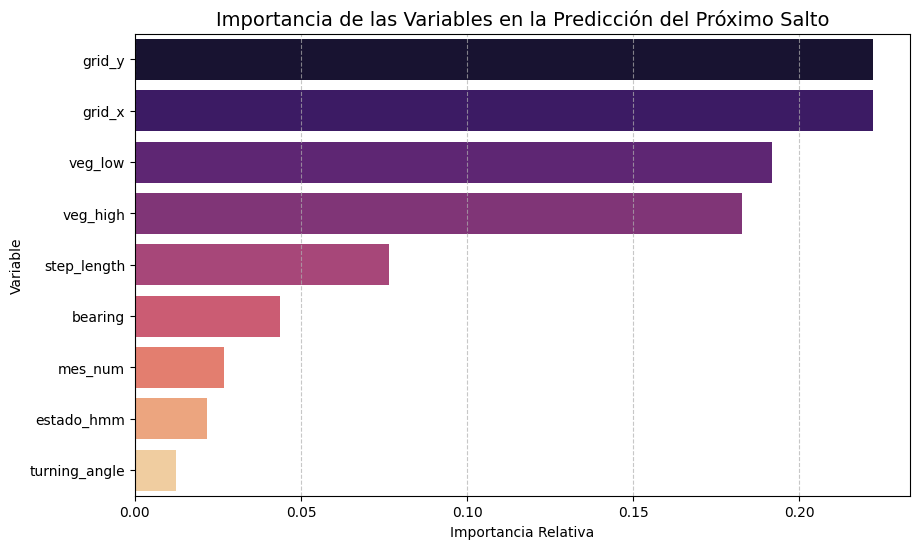

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extraer importancias del modelo ganador
importancias = pd.DataFrame({
    'Feature': features,
    'Importance': modelos["Random Forest"].feature_importances_
}).sort_values(by='Importance', ascending=False)

# Crear el gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importancias, palette='magma')
plt.title('Importancia de las Variables en la Predicción del Próximo Salto', fontsize=14)
plt.xlabel('Importancia Relativa')
plt.ylabel('Variable')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()